In [1]:
from background_db import *
import matplotlib.pyplot as plt

# Make background DB

BkgList(PSD, 28 bands)
  Energy range: 18.25 - 1999.75 keV
  Energy bins: 3964 (coverage: 3094/3964)
  Detectors: 19
  Bin size: 0.5 keV
BkgEband(PSD, cls_plaw_function)
  File: com_spec_params_e453_490_revidx_0043-2043.pkl
  Param table shape: (2, 42, 19, 2)
  Energy range: 453.25 - 489.75 keV
  Bin size: 0.5 keV
  Timescale: rev
[870 871 872 873 874 875 876 877 878 879 880 881 882 883 884 885 886 887
 888 889 890 891 892 893 894 895 896 897 898 899 900 901 902 903 904 905
 906 907 908 909 910 911 912 913 914 915 916 917 918 919 920 921 922 923
 924 925 926 927 928 929 930 931 932 933 934 935 936 937 938 939 940 941
 942 943]


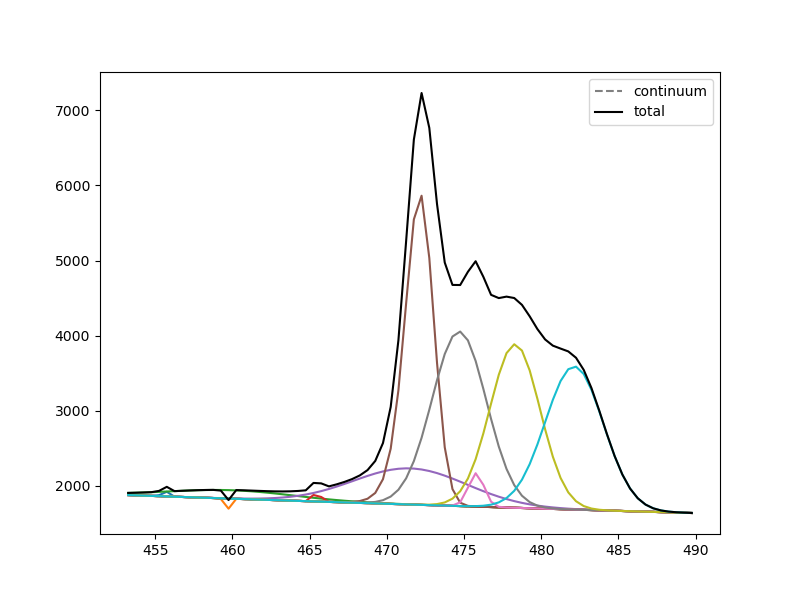

In [11]:
# spec_param_dir = '/data1/ipp_afs_mirror/integral/data/databases/spi_line_db/data/save/0043-2877'
%matplotlib widget
evt_type='PSD'
spec_param_dir= f'/Users/tbastro/SPI_analysis/BACKGROUND/BG_SAV/{evt_type}/'
bkg_full = BkgList(spec_param_dir, evt_type=evt_type)
print(bkg_full)

ndet=0
for bkg in bkg_full.bkg_range_list[0:1]:
    print(bkg)
    print(bkg.chan_range)
    ax=bkg.calc_spec_pid_det_eband(pid=43, det=ndet, E=None, plot=True)
    plt.show()

BkgList(SE, 33 bands)
  Energy range: 18.25 - 1999.75 keV
  Energy bins: 3964 (coverage: 3254/3964)
  Detectors: 19
  Bin size: 0.5 keV
BkgEband(SE, cls_plaw_function)
  File: com_spec_params_e453_490_revidx_0043-2887.sav
  Param table shape: (2, 42, 19, 2596)
  Energy range: 453.25 - 489.75 keV
  Bin size: 0.5 keV
  Timescale: rev
[870 871 872 873 874 875 876 877 878 879 880 881 882 883 884 885 886 887
 888 889 890 891 892 893 894 895 896 897 898 899 900 901 902 903 904 905
 906 907 908 909 910 911 912 913 914 915 916 917 918 919 920 921 922 923
 924 925 926 927 928 929 930 931 932 933 934 935 936 937 938 939 940 941
 942 943]


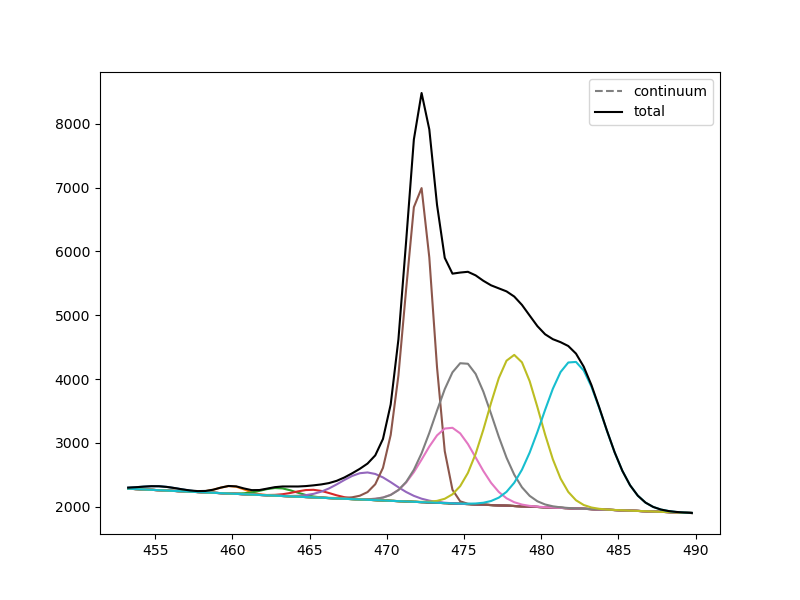

In [5]:
# spec_param_dir = '/data1/ipp_afs_mirror/integral/data/databases/spi_line_db/data/save/0043-2877'
evt_type='SE'
spec_param_dir= f'/Users/tbastro/SPI_analysis/BACKGROUND/BG_SAV/{evt_type}/'
bkg_full = BkgList(spec_param_dir, evt_type=evt_type)
print(bkg_full)

# for ndet in range(3):
ndet=0
for bkg in bkg_full.bkg_range_list[11:12]:
    print(bkg)
    print(bkg.chan_range)
    ax=bkg.calc_spec_pid_det_eband(pid=43, det=ndet, E=None, plot=True)
    plt.show()

## all energy range

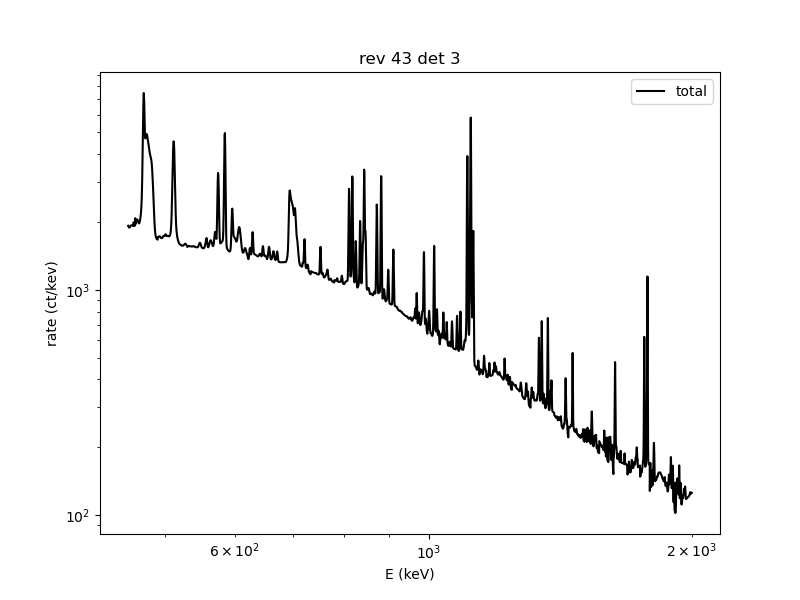

In [7]:
%matplotlib widget
det=3
pid=43
ax=bkg_full.calc_spec_pid_det(pid=pid, det=det, plot=True)

plt.show()

In [12]:
bkg_full.get_available_pid_list()

array([  43,   44,   45, ..., 2885, 2886, 2887],
      shape=(2596,), dtype=int32)

In [8]:
pid_list=np.arange(43, 44, dtype='int64')
# pid_list=np.arange(1, 5, dtype='int64')
bkg_full.write_fits_files(bkg_db_dir=f'/Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB', pid_list=pid_list, compress=True)

100%|██████████| 1/1 [00:00<00:00,  5.04it/s]


background successfully written in /Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB/PSD


## create livetime fits file

In [4]:
sav=readsav(f"/Users/tbastro/SPI_analysis/BACKGROUND/spi_det_hi_full_mission.sav")


/Users/tbastro/miniconda3/envs/compton/lib/python3.13/site-packages/scipy/io/_idl.py:338: UserWarning: Using experimental 64-bit array read
  rectypedesc = _read_typedesc(f)


In [ ]:
# 'x_hi', 'yann_hi', 'yse_hi', 'ydet_hi', 'rdx', 'det_time', 'det_time_ann', 'ann']
sav['det_time_ann'], sav['ann']

(array([[3134992.59114793, 3148558.11113685, 3147340.9204736 , ...,
         3600556.76114152, 3602583.87802088, 3601929.22069867],
        [7524919.43421928, 7526931.32296353, 7524101.40699505, ...,
         7225024.84266602, 7229159.4609707 , 7227797.2969369 ],
        [5950526.51096882, 5952147.40467201, 5949856.67196301, ...,
         5708668.60316368, 5711955.77612436, 5710865.74808191],
        ...,
        [8537728.09838824,       0.        ,       0.        , ...,
         8009284.27657888,       0.        ,       0.        ],
        [8254136.84433449,       0.        ,       0.        , ...,
         7713826.03134133,       0.        ,       0.        ],
        [8465196.99488987,       0.        ,       0.        , ...,
         7901858.0234111 ,       0.        ,       0.        ]],
       shape=(34, 61), dtype='>f8'),
 array([[  16,   43,   97,  141,  216,  283,  331,  401,  453,  512,  572,
          648,  721,  777,  803,  864,  917,  931,  983, 1049, 1120, 1185,
       

In [1]:
from background_db import make_det_livetime_fits
make_det_livetime_fits(f"/Users/tbastro/SPI_analysis/BACKGROUND/spi_det_hi_full_mission.sav", fits_file=None, period_type='annealing')


/Users/tbastro/miniconda3/envs/compton/lib/python3.13/site-packages/scipy/io/_idl.py:338: UserWarning: Using experimental 64-bit array read
  rectypedesc = _read_typedesc(f)


FITS file created: det_livetime_annealing.fits


# Create scw background

In [1]:
from obs_background import *

loading scw info
load energy bounds
loading observation live times
Initialize data base meta
Initialize revolution backgrounds from data base
Calculating background for 64 pointings, 19 detectors
calc_bkg took 0.001s
Available background types: ['CONTINUUM', 'LINES']
Shape of first background type: (1216, 41, 2)


<Axes: title={'center': 'Background (scw 0, det 0)'}, xlabel='Energy (keV)', ylabel='Counts'>

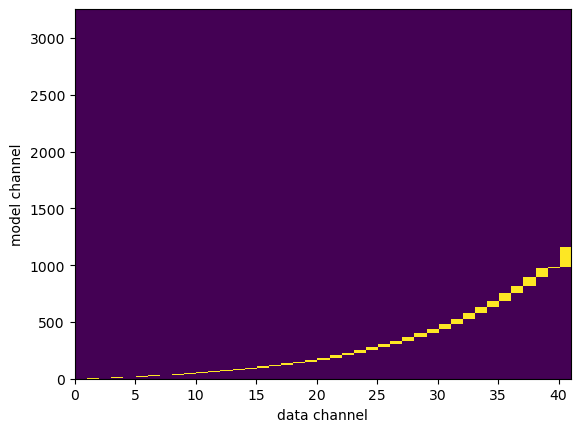

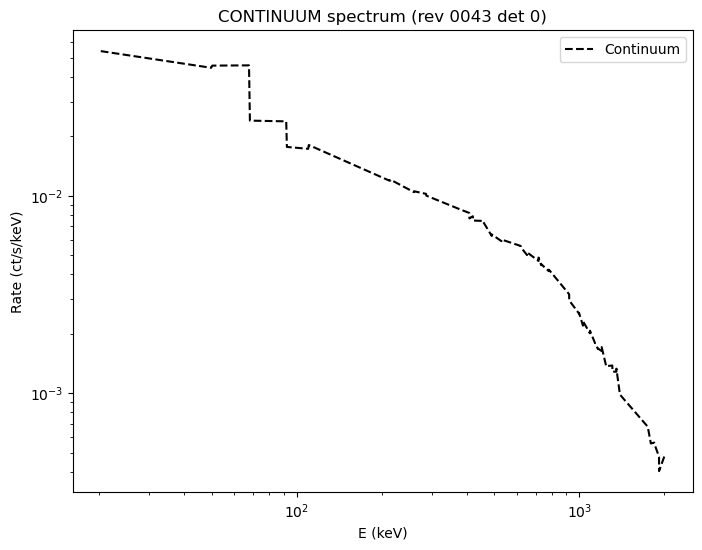

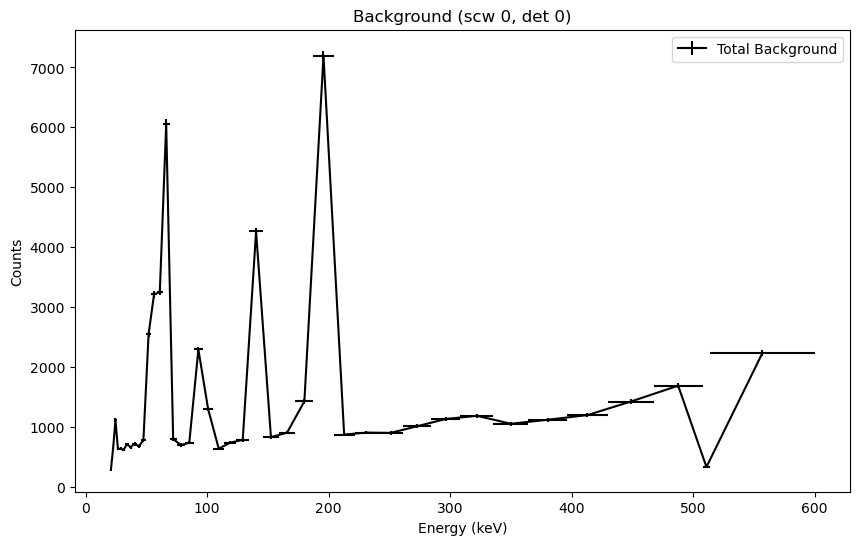

In [2]:
# %matplotlib widget
evt_type='SE'
main_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/crab_dir_test'
bkg_db_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB'
obs_bkg = ObsBkg(main_dir, evt_type)
livetime = LiveTimeRev(bkg_db_dir+'/det_livetime_rev.fits', evt_type)
obs_bkg.normalize_tracer(livetime)
obs_bkg.init_rev_bkg_list(livetime_rev=livetime, bkg_db_dir=bkg_db_dir)
obs_bkg.bkg_rev_list[0].plot_rbn_mat()
obs_bkg.bkg_rev_list[0].plot(det=0)

bkg_dict = obs_bkg.calc_bkg()
print("Available background types:", list(bkg_dict.keys()))
print("Shape of first background type:", bkg_dict[list(bkg_dict.keys())[0]].shape)
obs_bkg.plot_bkg(scw_idx=0, det=0, bkg_types=None, type_spec='counts')

In [ ]:
a=livetime.det_time[2003]


(np.float64(148373.18146350633), np.float64(0.0), np.float64(0.0), np.float64(148362.82551628855), np.float64(148289.52726189856), np.float64(0.0), np.float64(148372.8495685122), np.float64(148597.15151413006), np.float64(148527.63367429812), np.float64(148599.1249488472), np.float64(148463.94130272316), np.float64(148534.3935663525), np.float64(148853.4151553687), np.float64(148693.2458891123), np.float64(148524.84664821744), np.float64(148448.70415456558), np.float64(148652.66995959685), np.float64(0.0), np.float64(148605.6487752155))

In [3]:
obs_bkg.write_output_bkg('./output_test')

Creating output dir: ./output_test
Writting CONTINUUM...
Written ./output_test/output_bgmodel-conti.fits.gz
Writting LINES...
Written ./output_test/output_bgmodel-lines.fits.gz
Written ./output_test/output_bgmodel_conti_sep_idx.fits.gz
write_output_bkg took 0.132s


## per detector

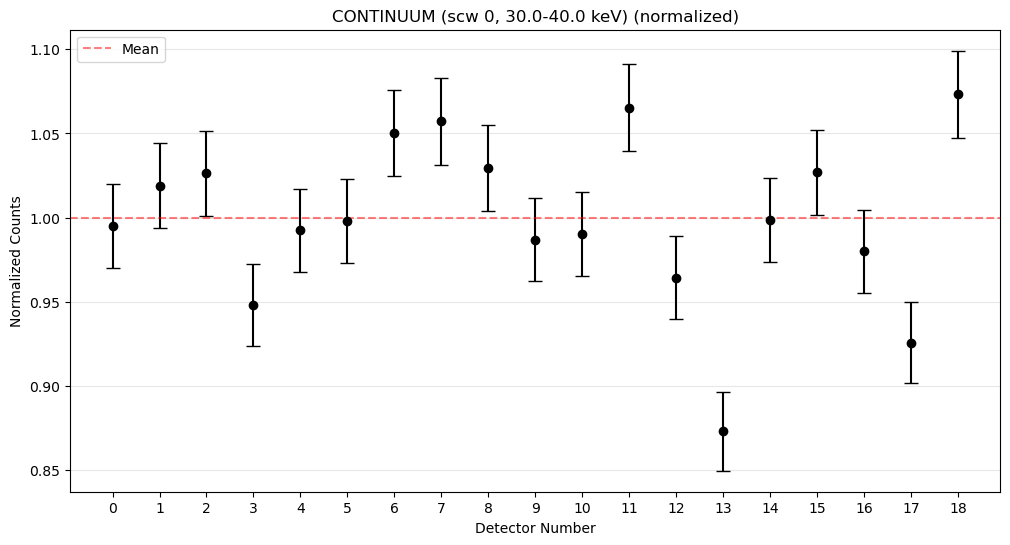

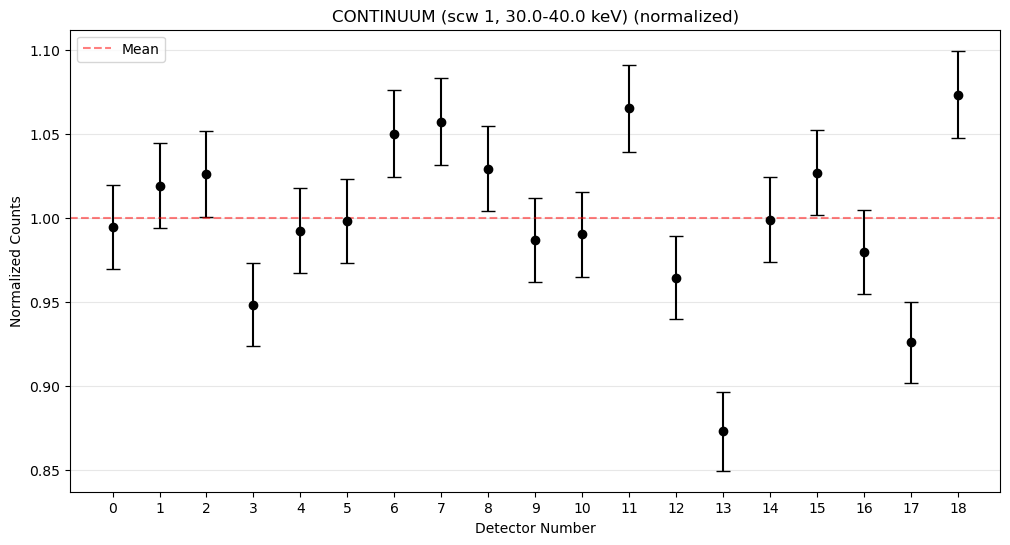

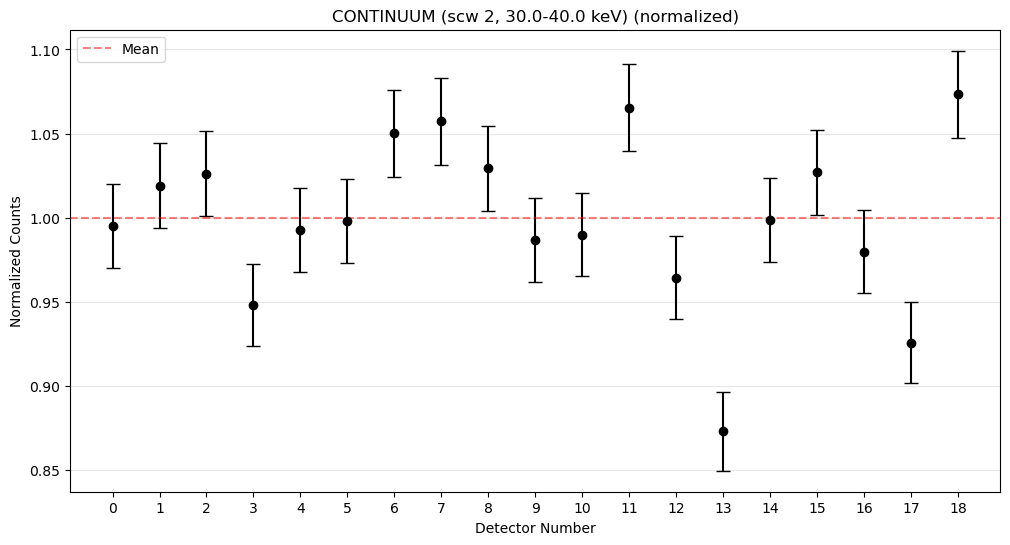

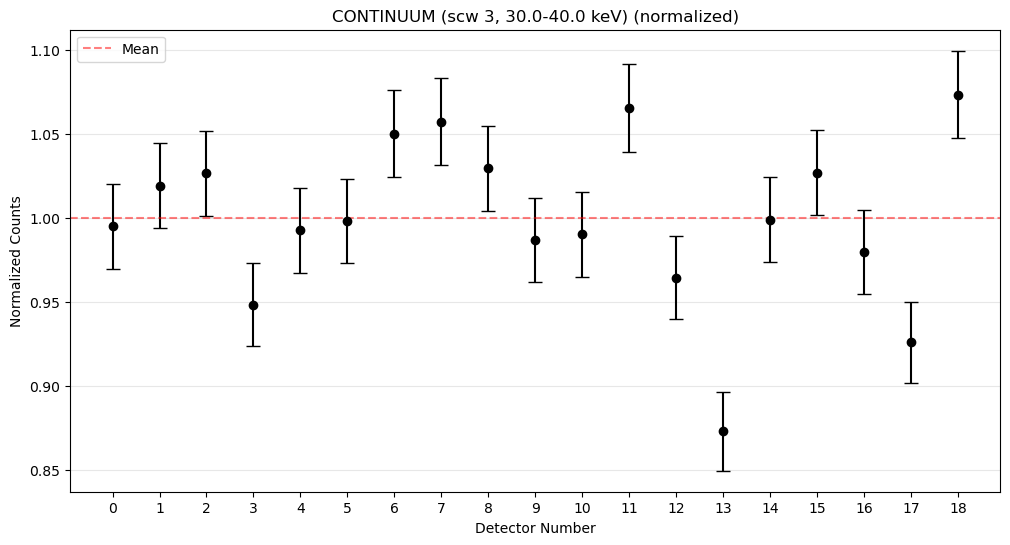

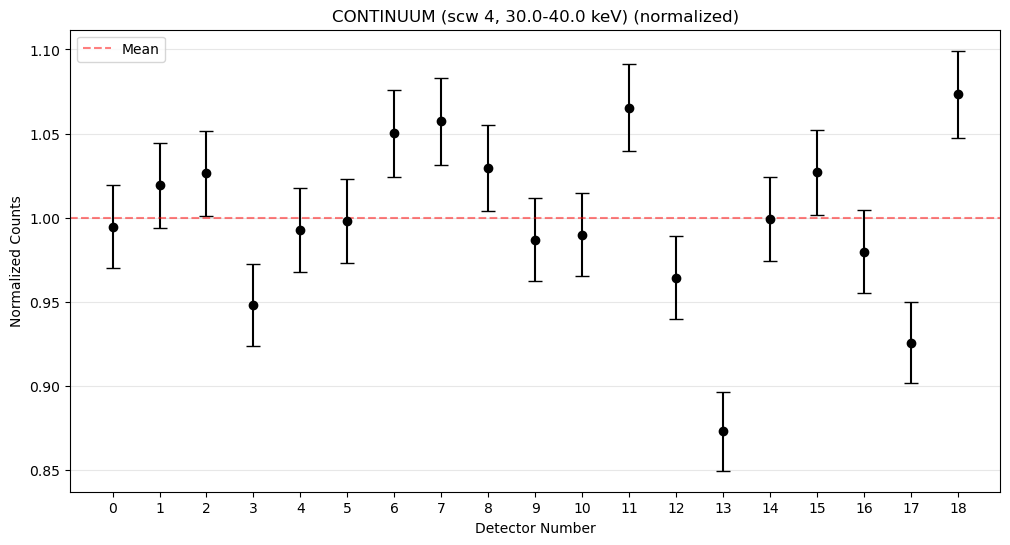

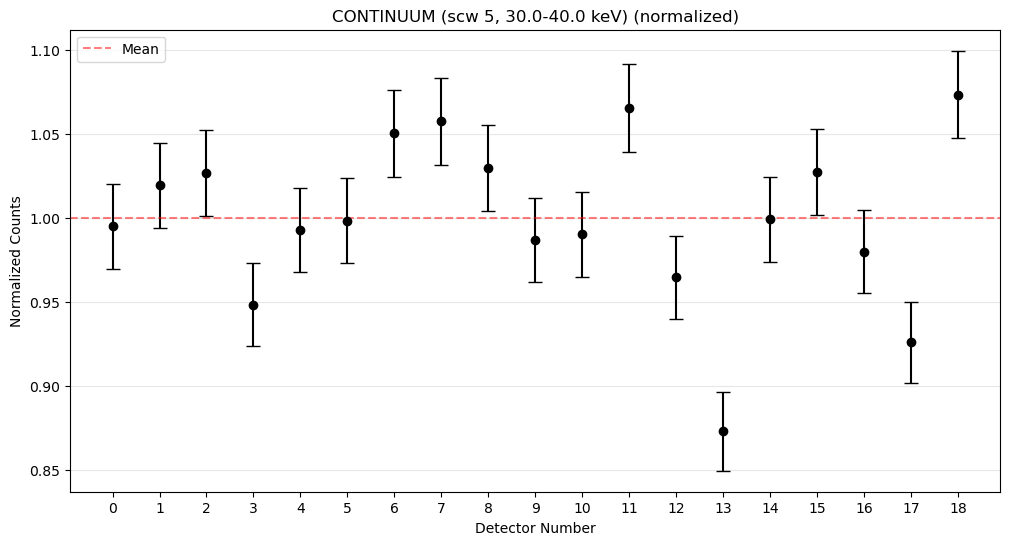

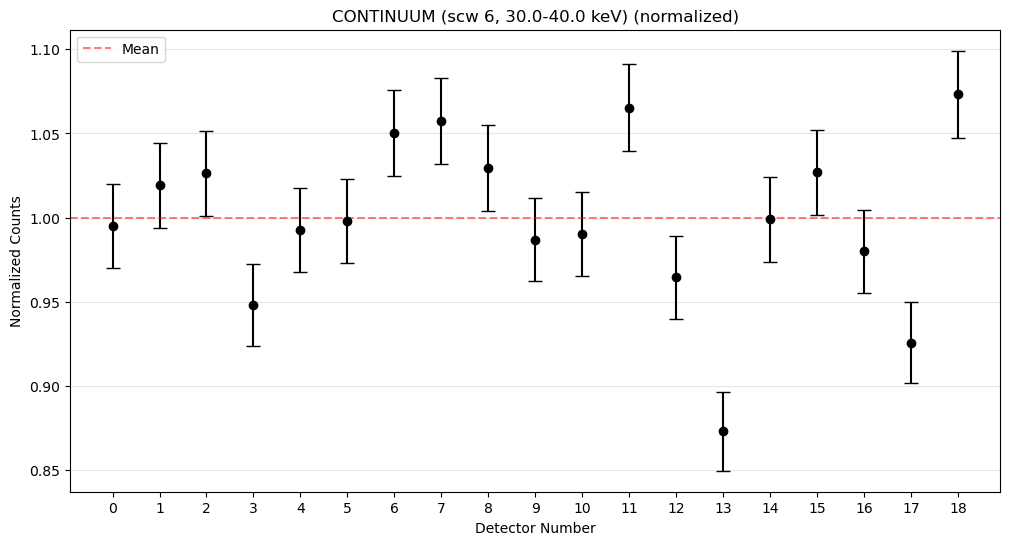

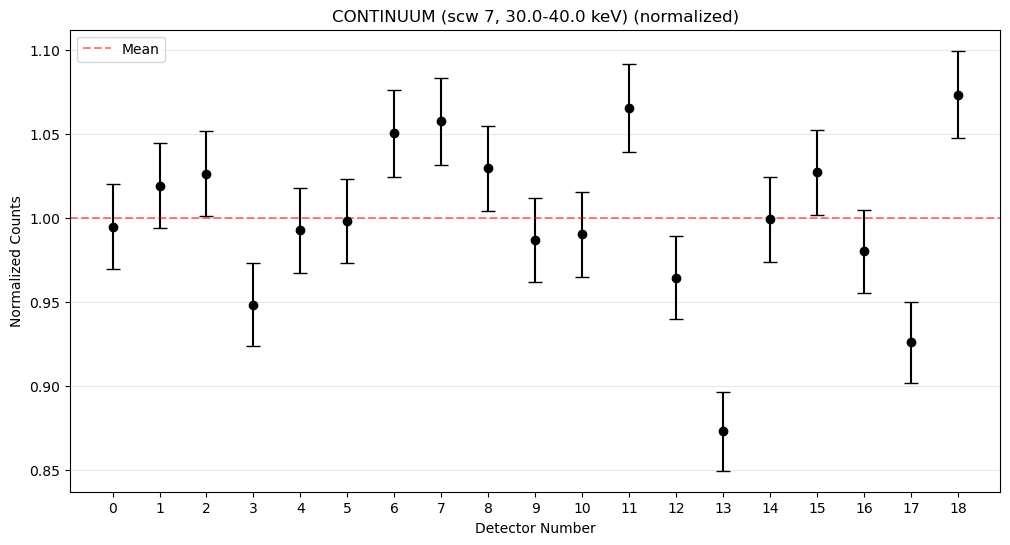

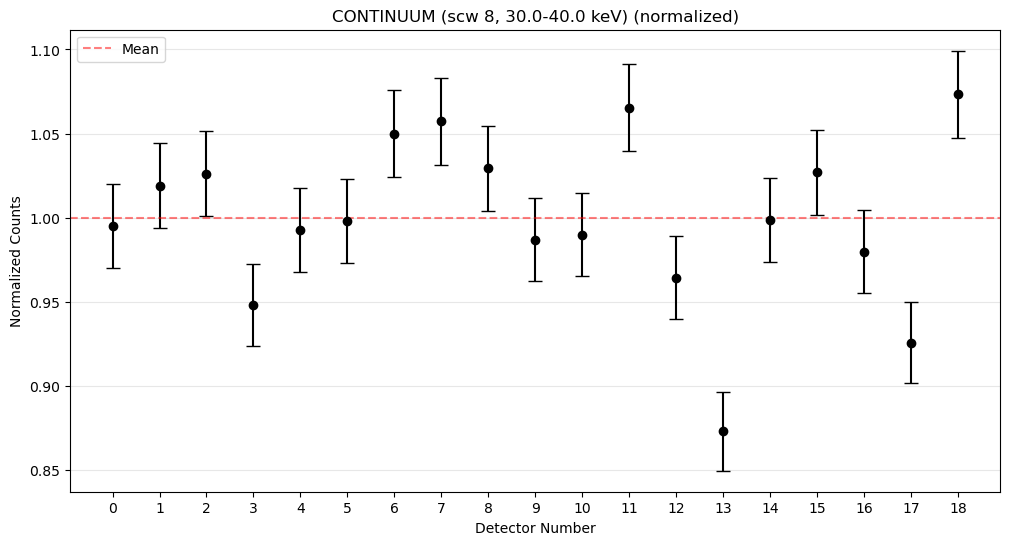

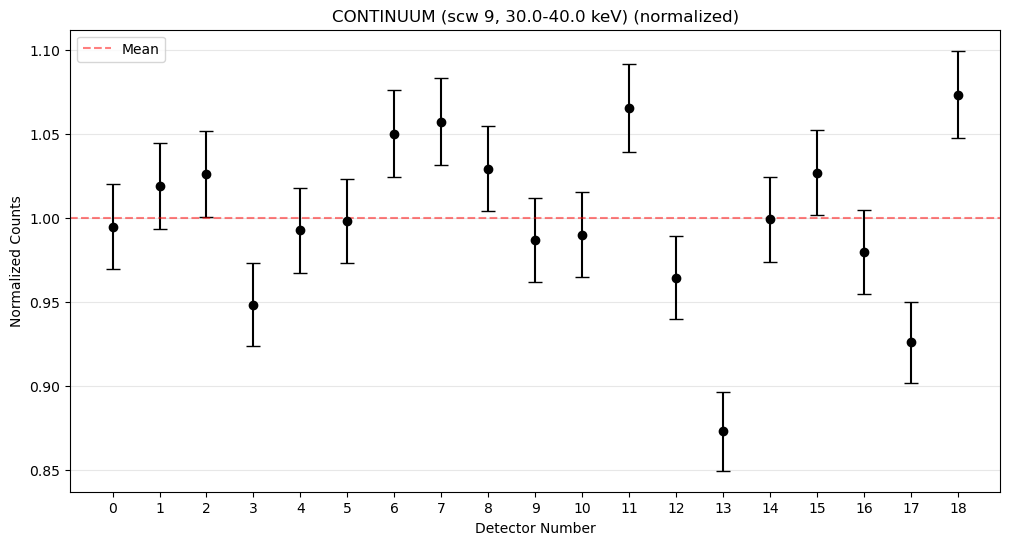

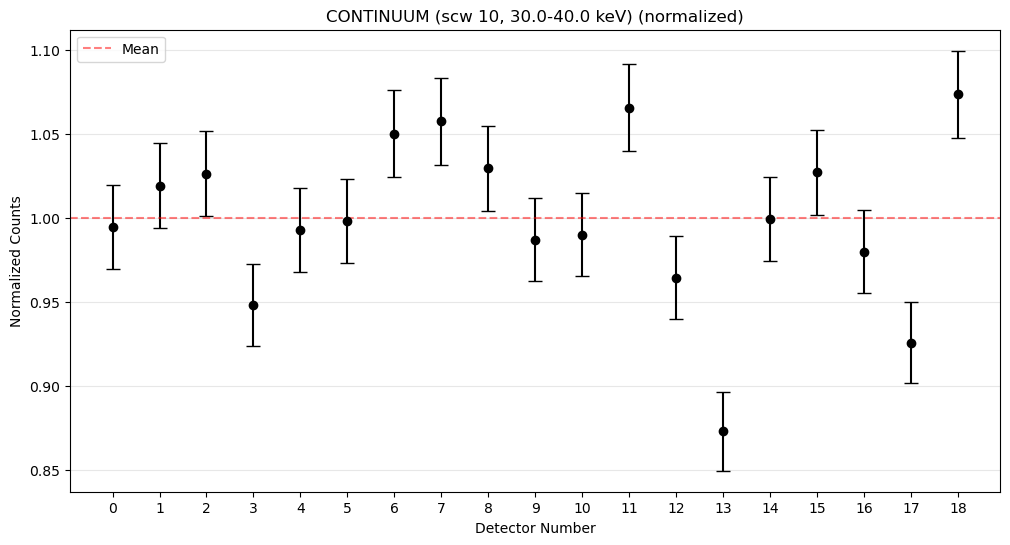

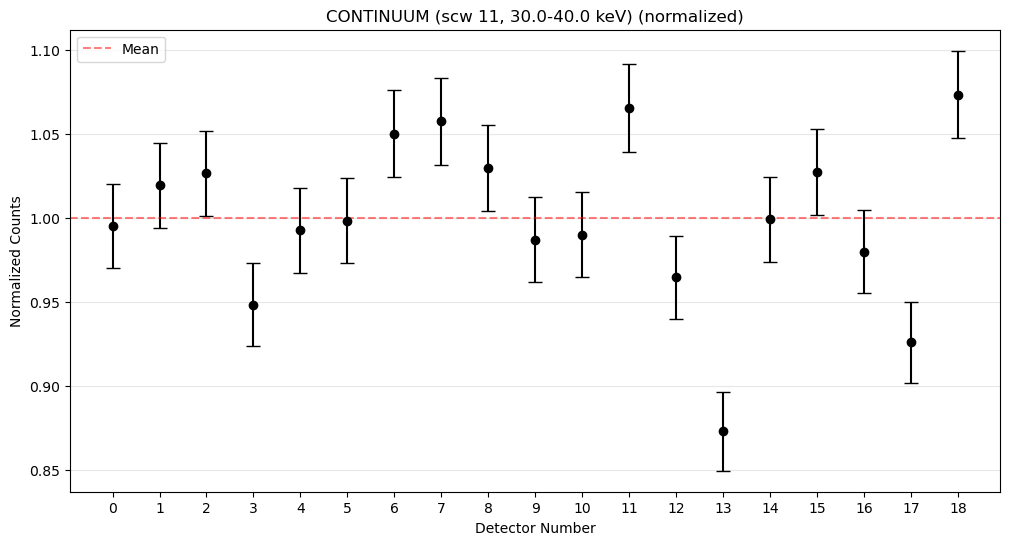

In [3]:
for scw_idx in range(12):
    # ax=obs_bkg.plot_bkg_by_detector(scw_idx, 30, 40, None, normalize=True)
    ax=obs_bkg.plot_bkg_by_detector(scw_idx, 30, 40, 'CONTINUUM', normalize=True)
    # ax.set_ylim(.8, .88)
    plt.show()

## comparison

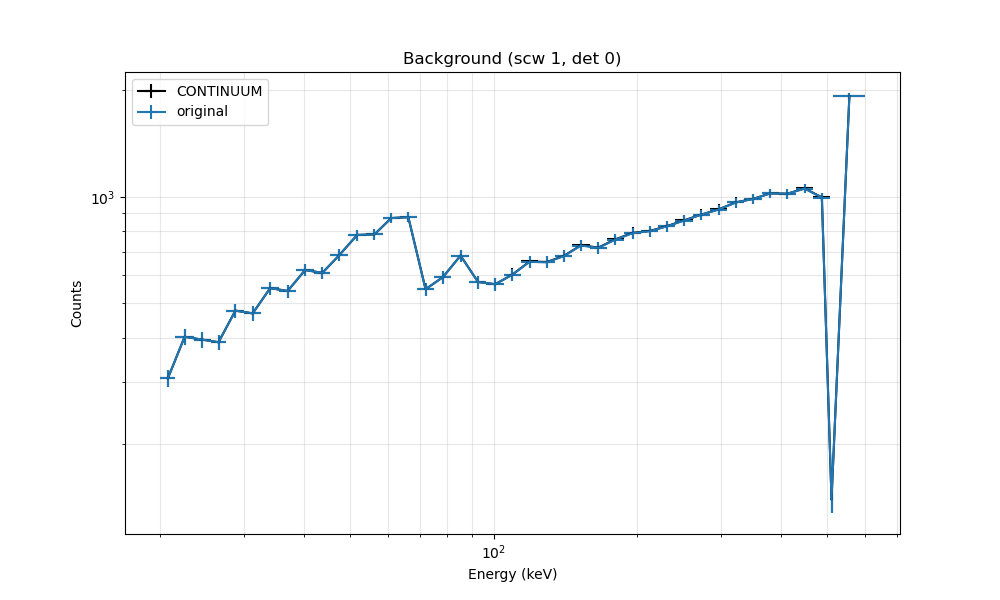

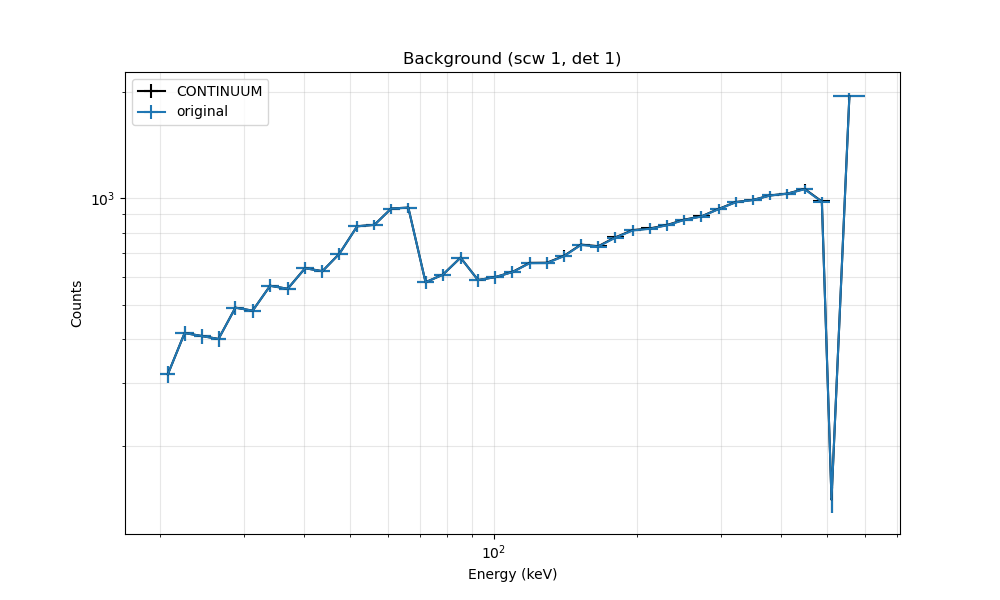

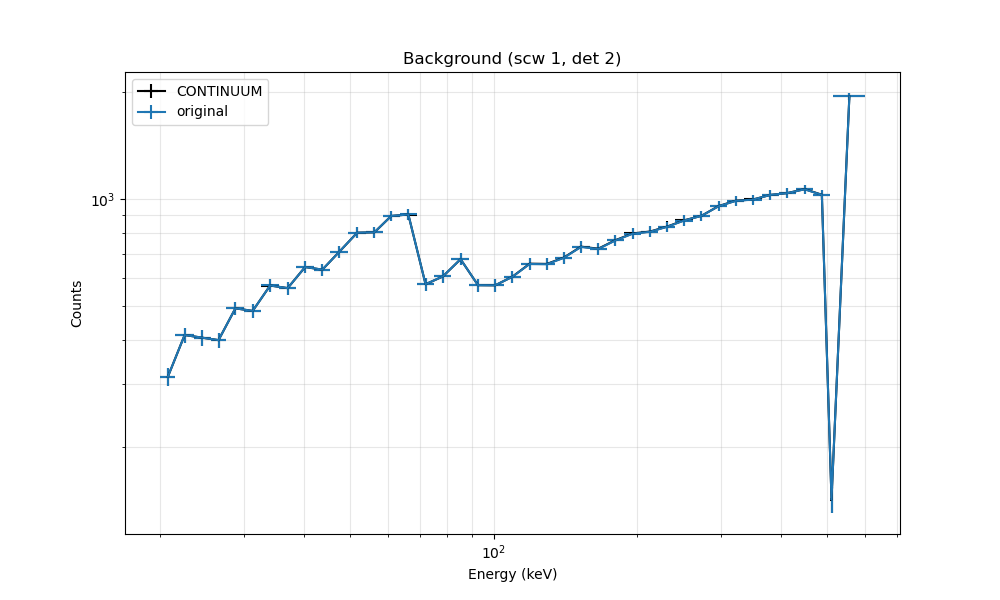

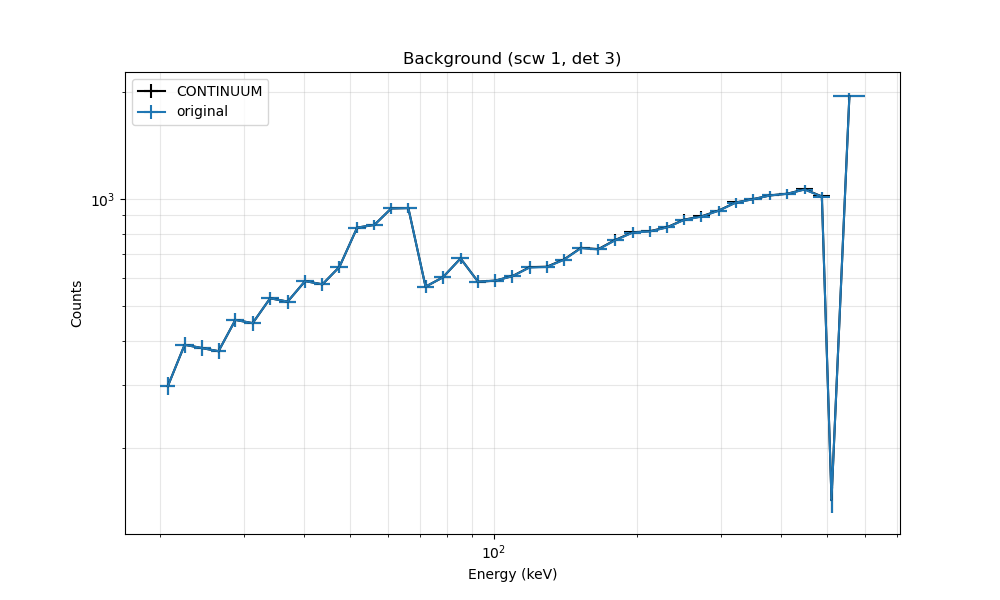

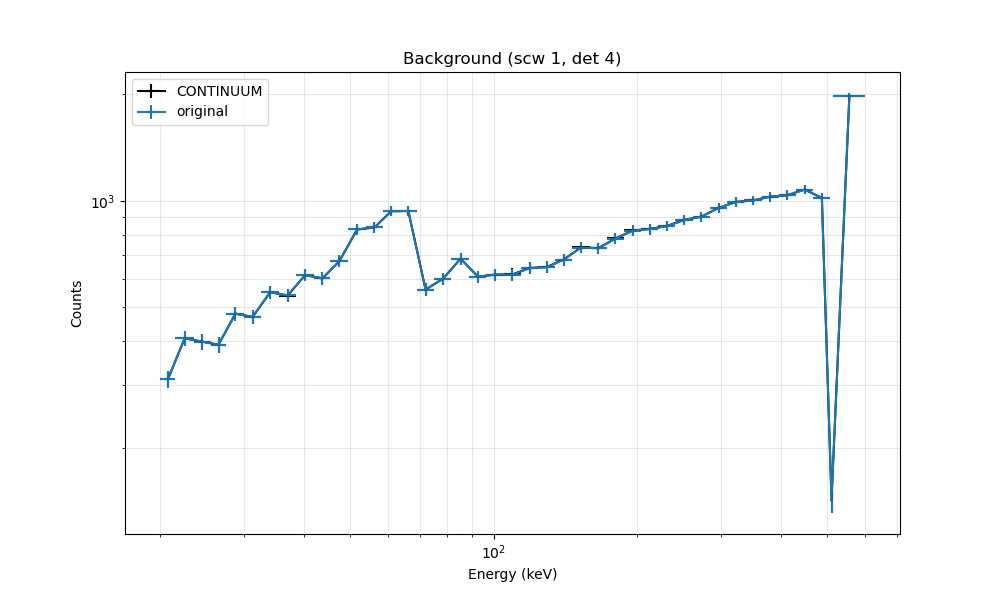

In [12]:
# %matplotlib widget
def check_output(dir='background_output/', file='output_bgmodel-conti.fits'):
    hdul=fits.open(dir+file)
    data=hdul[1].data
    return data

# out_dir='cookbook_dataset_02_0020-0600keV_SE/spi/bg-e0020-0600/' # old cookbook directory from 2013 
out_dir=f'/Users/tbastro/SPI_analysis/BACKGROUND/cookbook_dataset_02_0020-0600keV_SE_new/spi/bg-e0020-0600/' # fresh analysis from 2024
data_conti=check_output(dir=out_dir, file='output_bgmodel-conti.fits.gz')
data_sumlines=check_output(dir=out_dir, file='output_bgmodel-lines.fits.gz')
scw_idx = 1
bkg_type='CONTINUUM'
for det in range(5):
    # ax = obs_bkg.plot_bkg(scw_idx=det, det=scw_idx, bkg_types=[bkg_type], type_spec='counts') # reverse det/scw
    ax = obs_bkg.plot_bkg(scw_idx=scw_idx, det=det, bkg_types=[bkg_type], type_spec='counts')
    if bkg_type=='LINES':
        ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_sumlines[scw_idx*19+det][0], yerr=data_sumlines[scw_idx*19+det][1],label='original')
        ax.set_xscale('log')
    elif bkg_type=='CONTINUUM':
        ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_conti[scw_idx*19+det][0], yerr=data_conti[scw_idx*19+det][1],label='original')
        ax.loglog()
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.show()

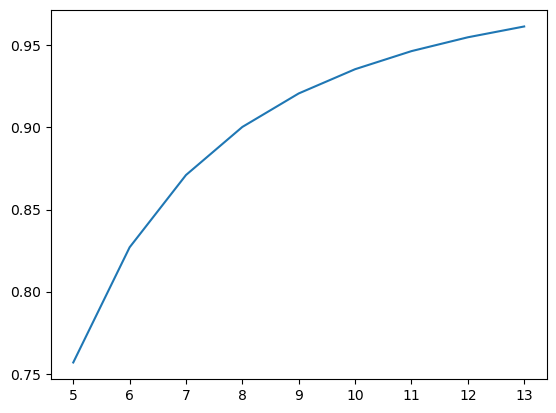

In [5]:
x=np.arange(5,14)
y=np.sin(2*np.pi/x)/(2*np.pi/x)
plt.plot(x,y)


det 0 scw 6: ratio stderr 7.9e-04 (<1e-3)
det 1 scw 6: ratio stderr 7.8e-04 (<1e-3)
det 2 scw 6: ratio stderr 7.6e-04 (<1e-3)
det 3 scw 6: ratio stderr 7.3e-04 (<1e-3)
det 4 scw 6: ratio stderr 6.8e-04 (<1e-3)
det 5 scw 6: ratio stderr 7.1e-04 (<1e-3)
det 6 scw 6: ratio stderr 7.7e-04 (<1e-3)
det 7 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 8 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 9 scw 6: ratio stderr 8.4e-04 (<1e-3)
det 10 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 11 scw 6: ratio stderr 8.2e-04 (<1e-3)
det 12 scw 6: ratio stderr 8.4e-04 (<1e-3)
det 13 scw 6: ratio stderr 7.7e-04 (<1e-3)
det 14 scw 6: ratio stderr 8.2e-04 (<1e-3)
det 15 scw 6: ratio stderr 8.8e-04 (<1e-3)
det 16 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 17 scw 6: ratio stderr 7.9e-04 (<1e-3)
det 18 scw 6: ratio stderr 8.9e-04 (<1e-3)


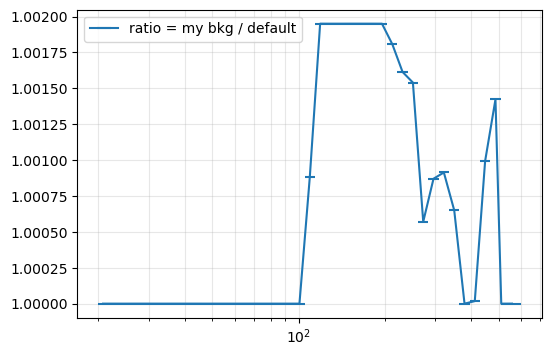

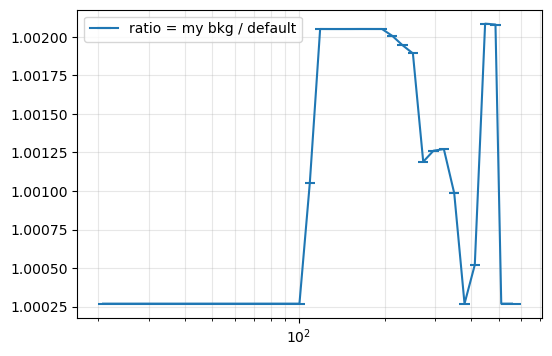

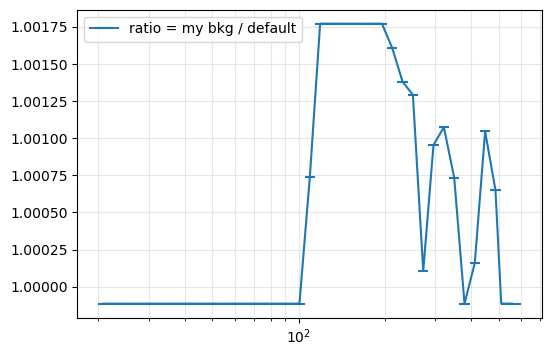

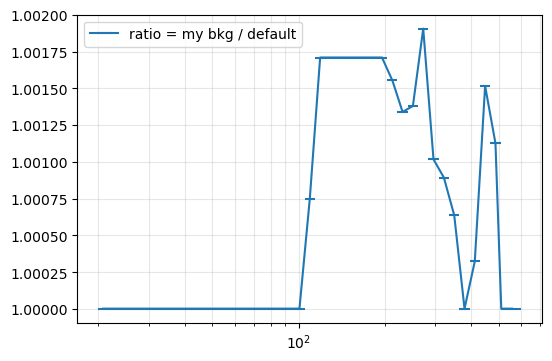

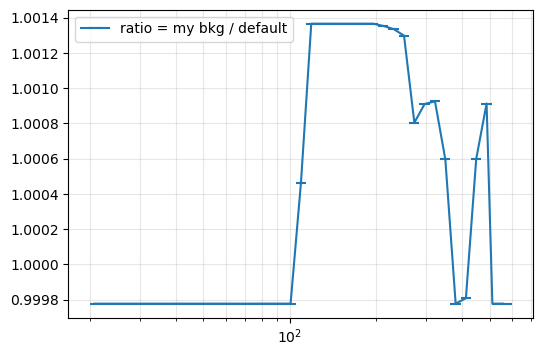

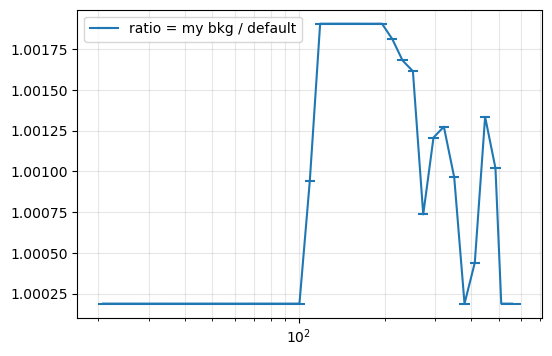

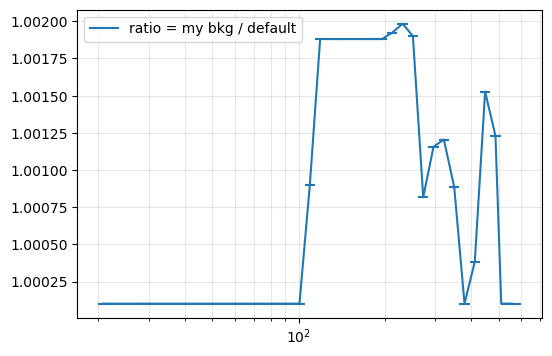

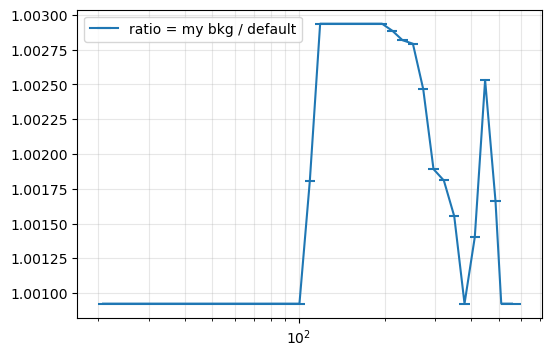

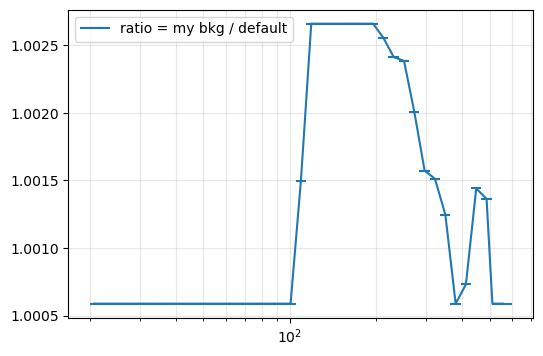

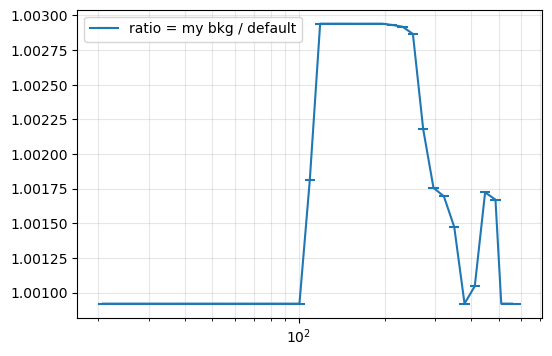

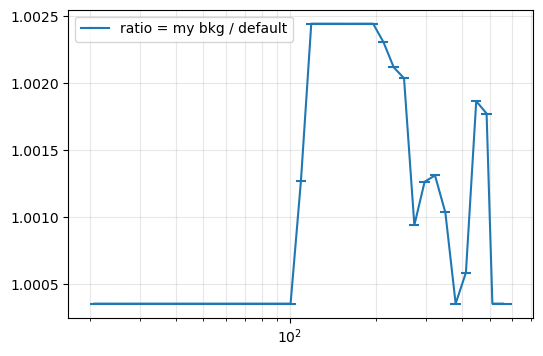

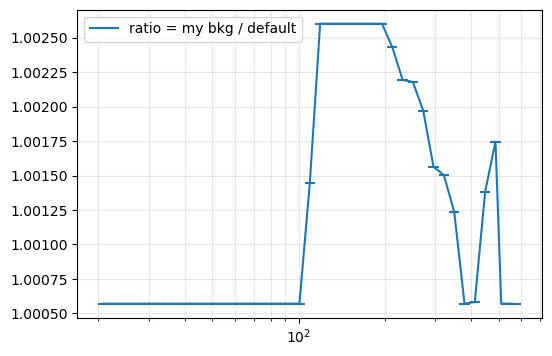

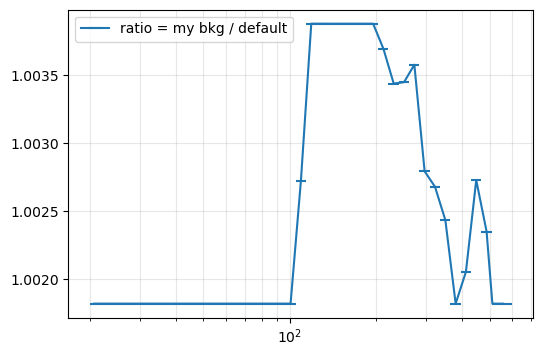

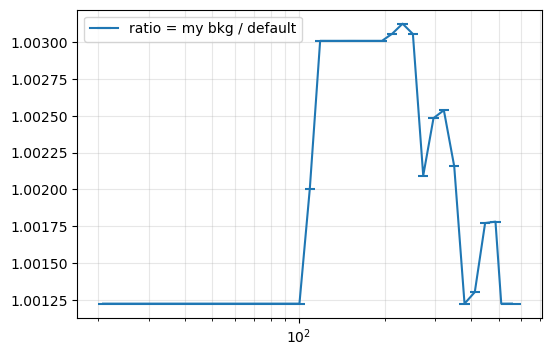

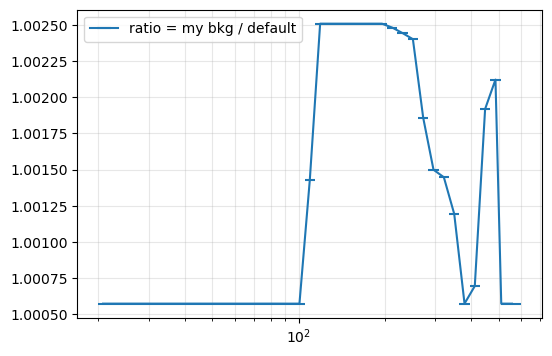

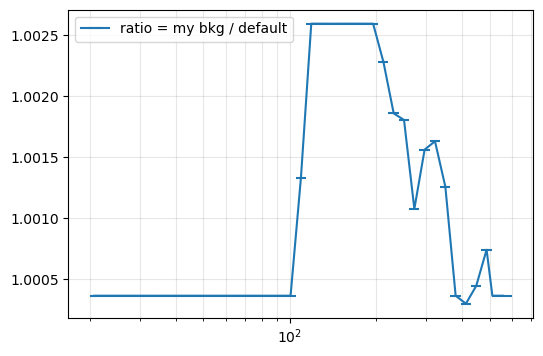

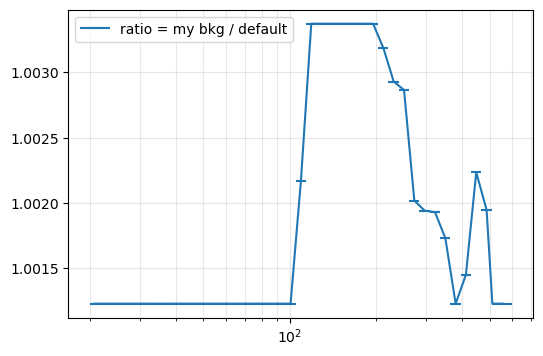

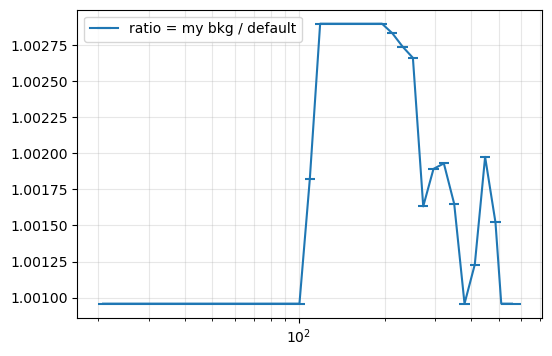

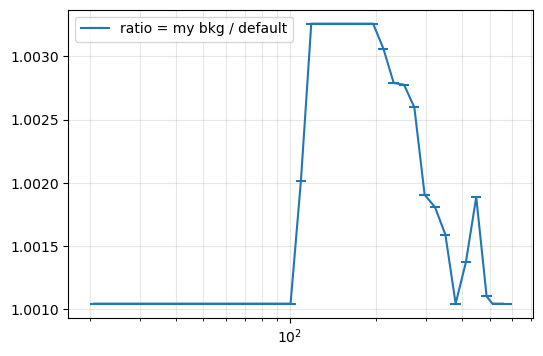

In [5]:
%matplotlib inline
scw_idx=6
for det in range(19):
    print(f'det {det} scw {scw_idx}: ', end='')
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ratio=obs_bkg.bkg_output_dico['CONTINUUM'][det + obs_bkg.det_num * scw_idx][:,0] / data_conti[scw_idx*19+det][0]
    # ratio=obs_bkg.bkg_output_dico['LINES'][det + obs_bkg.det_num * scw_idx] / data_sumlines[scw_idx*19+det][0]
    print(f'ratio stderr {ratio.std():.1e}'+int(ratio.std()<1e-3)*' (<1e-3)')
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y=ratio,label='ratio = my bkg / default')
    # ratio=obs_bkg.bkg_output_dico['CONTINUUM'][det + obs_bkg.det_num * scw_idx] / data[scw_idx*19+det][0]
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    # plt.show()

## raw spectrum

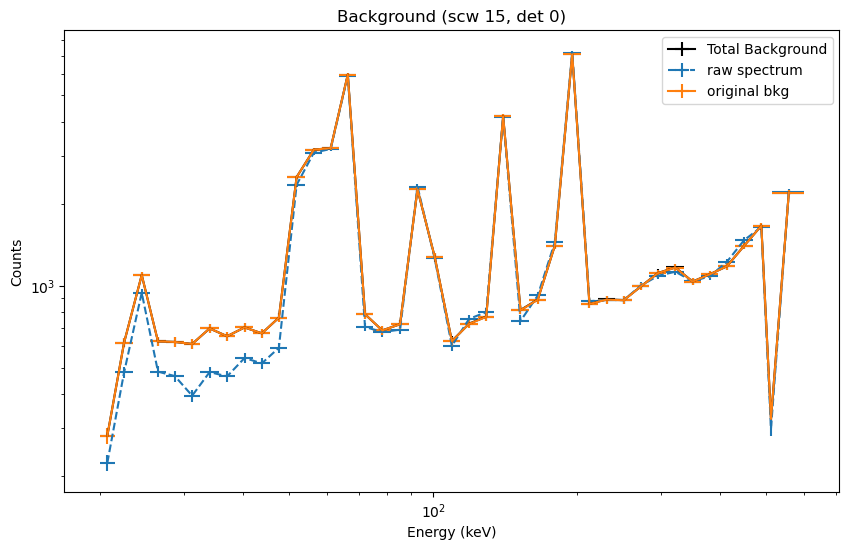

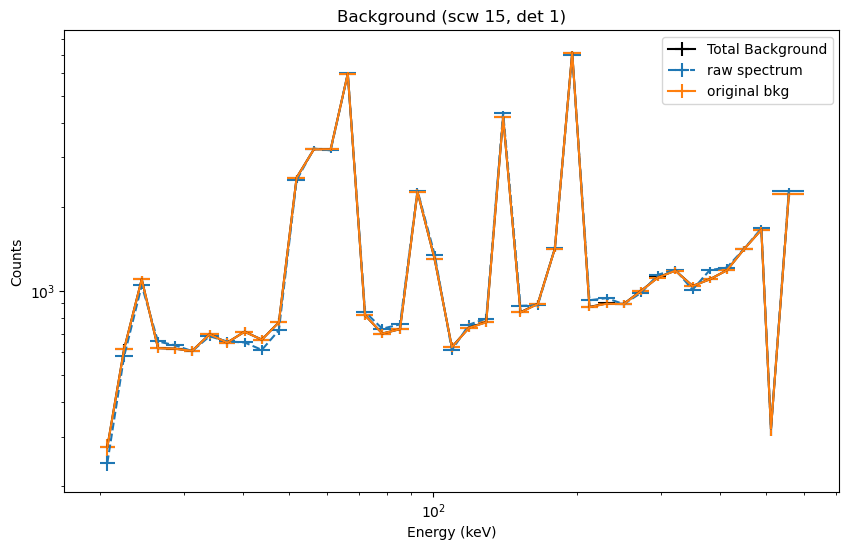

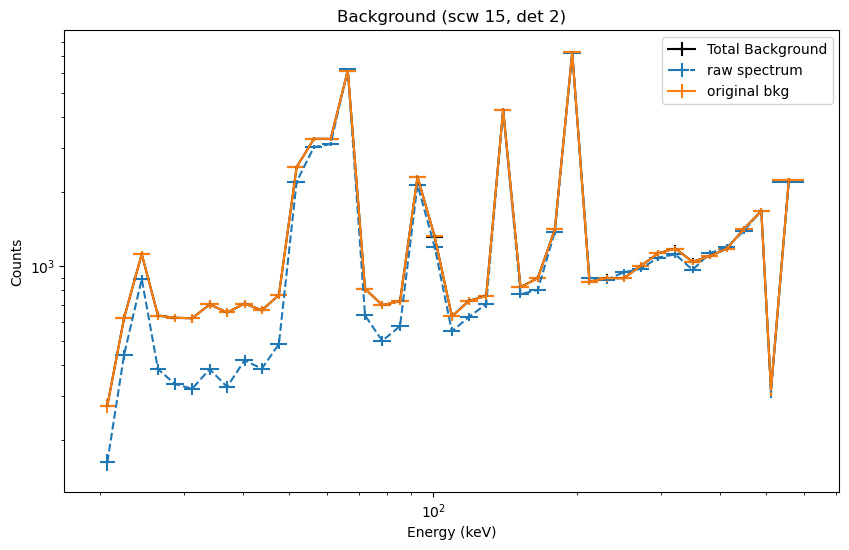

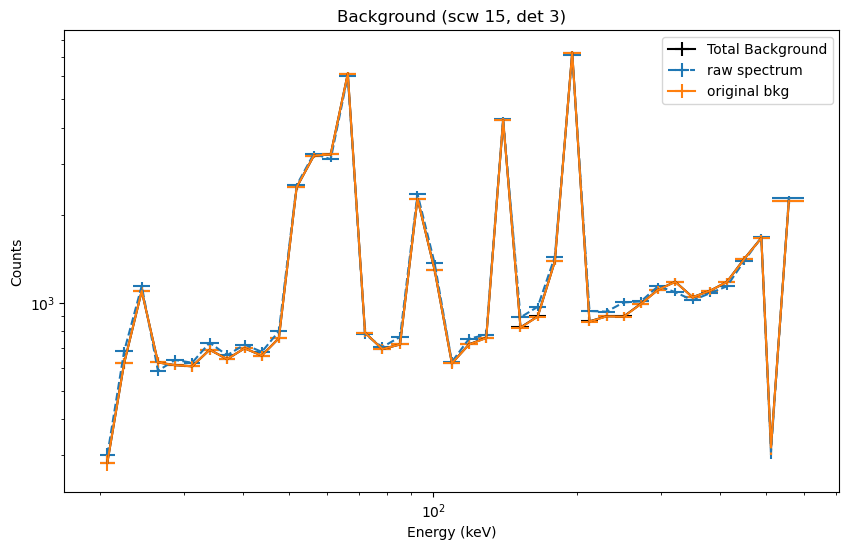

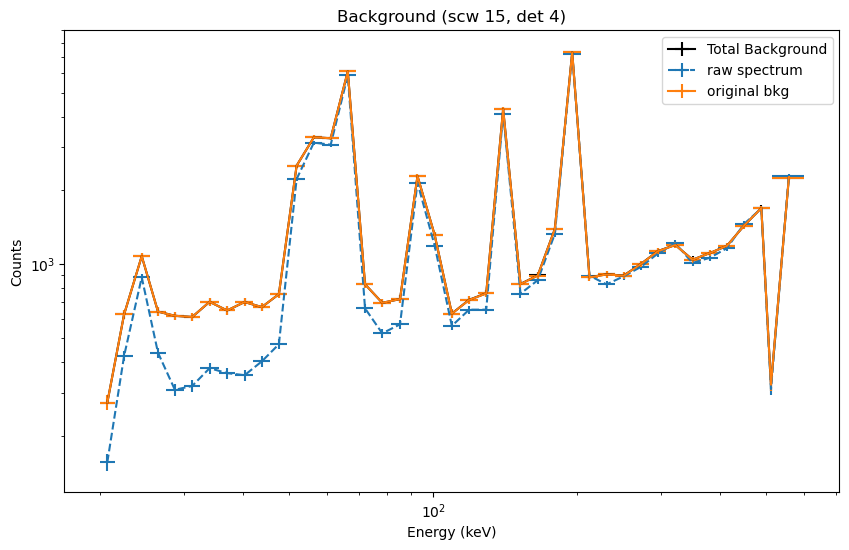

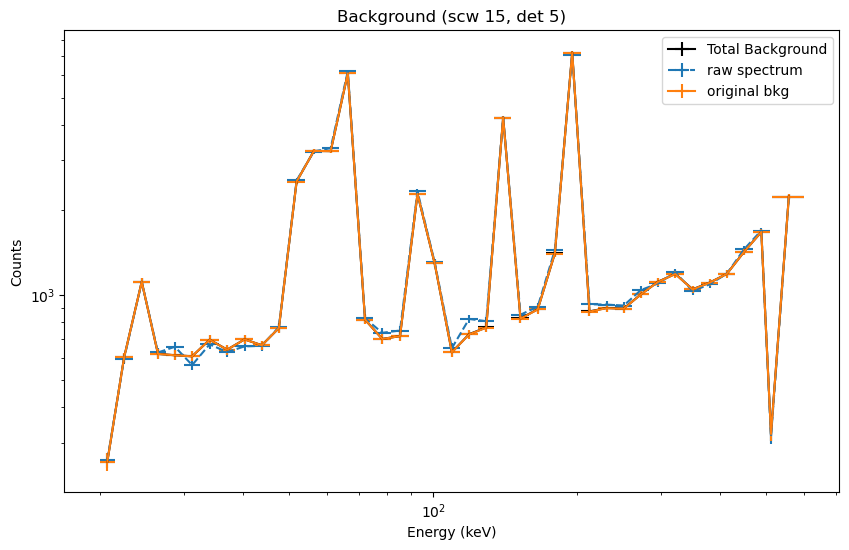

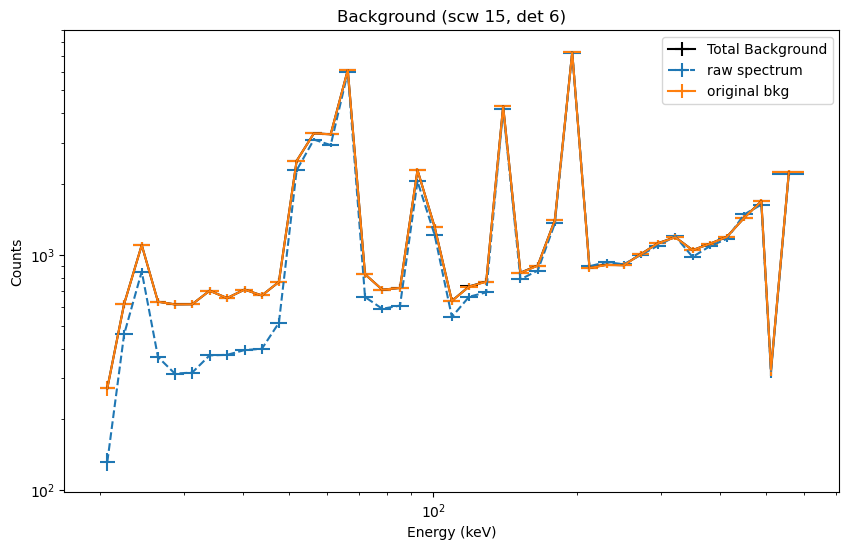

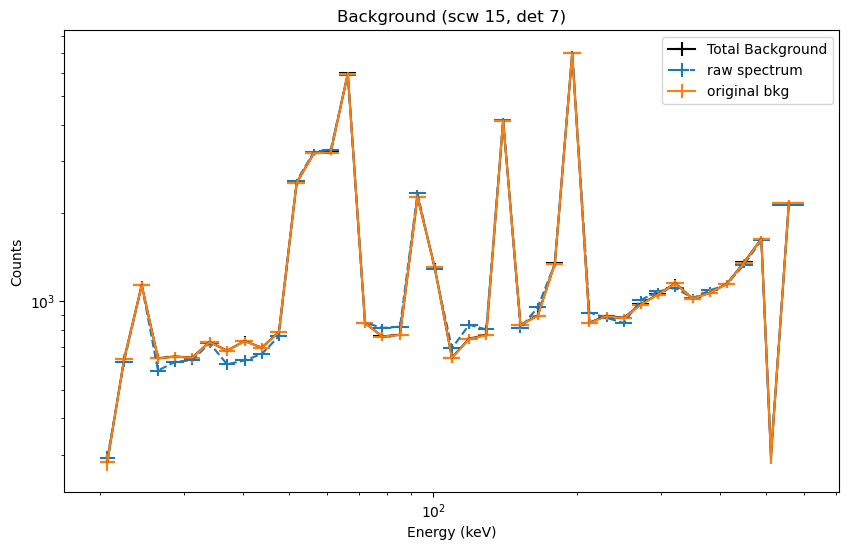

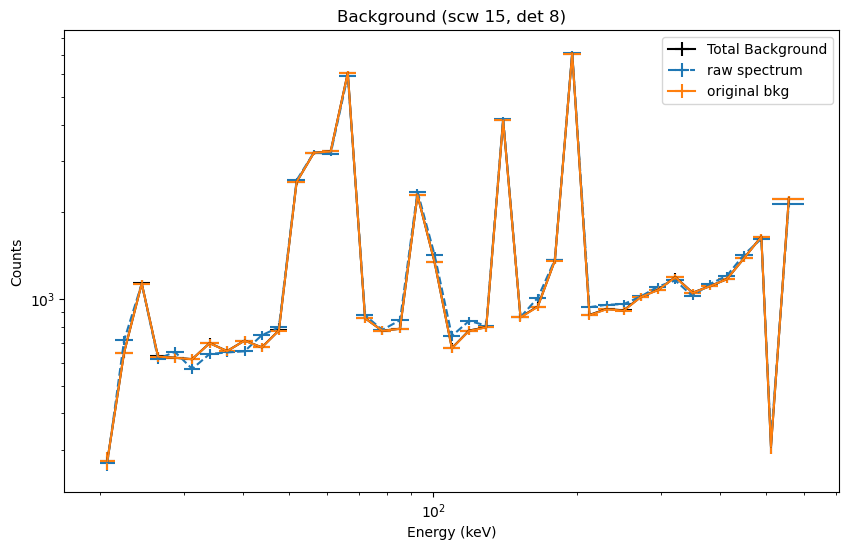

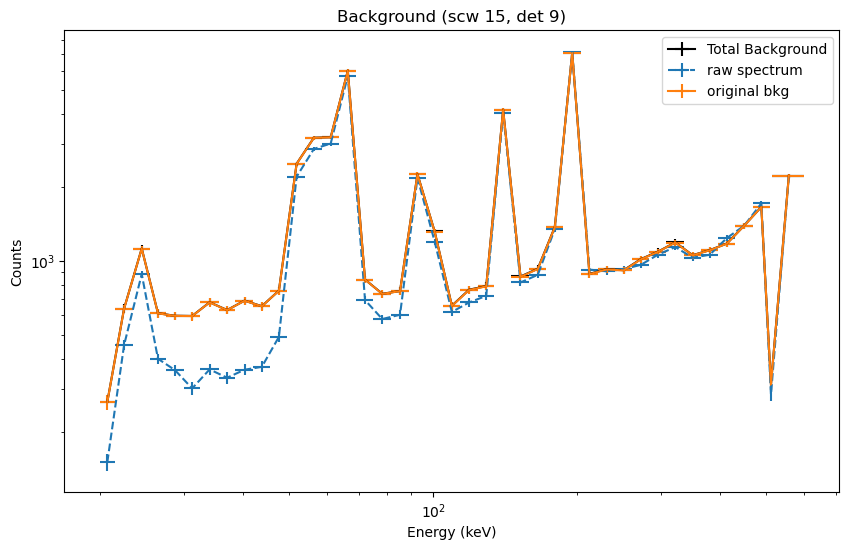

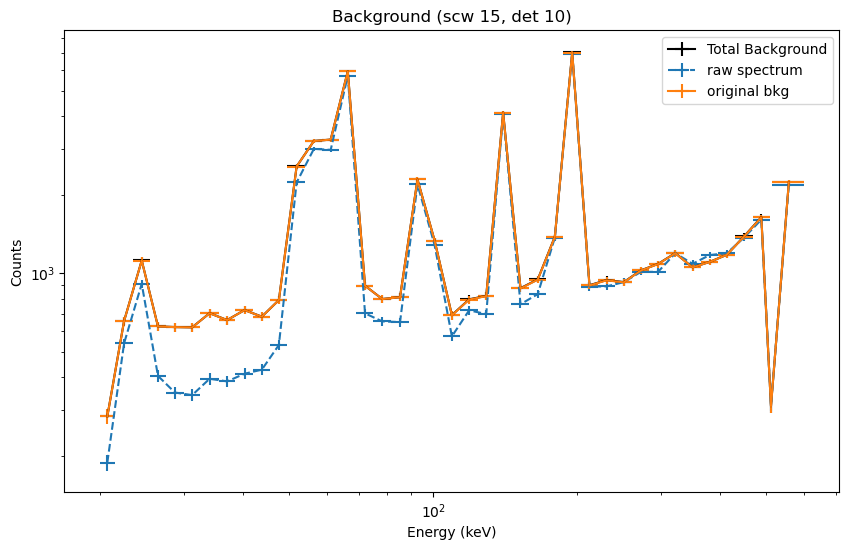

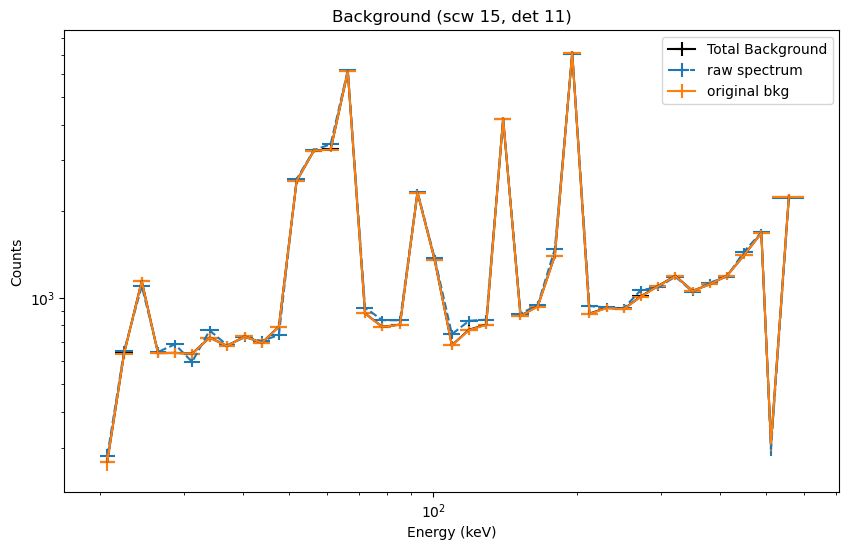

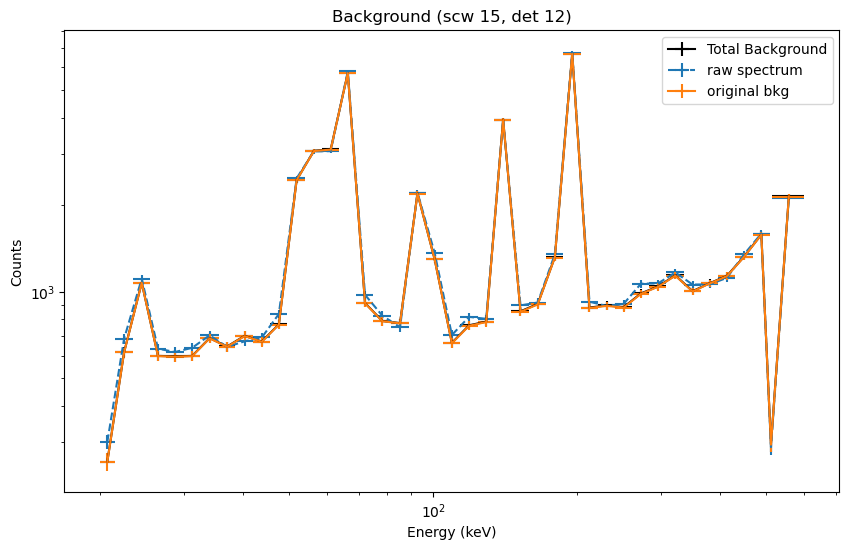

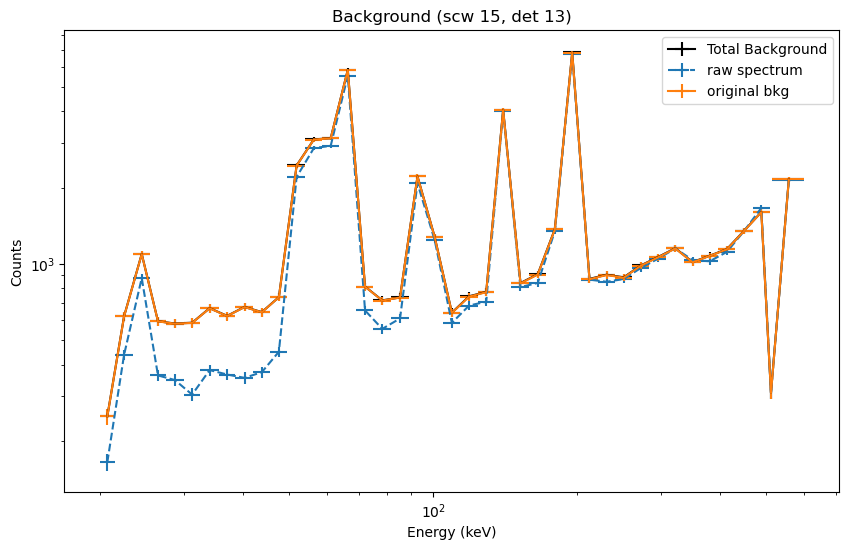

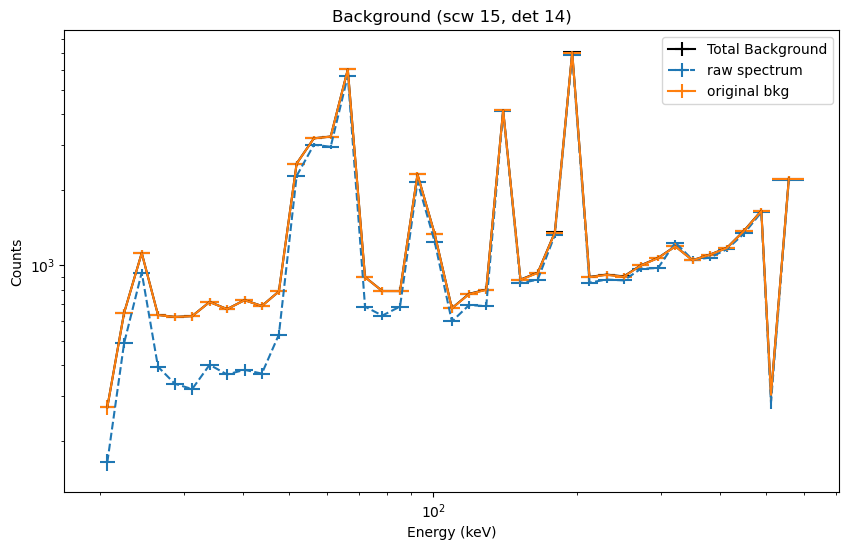

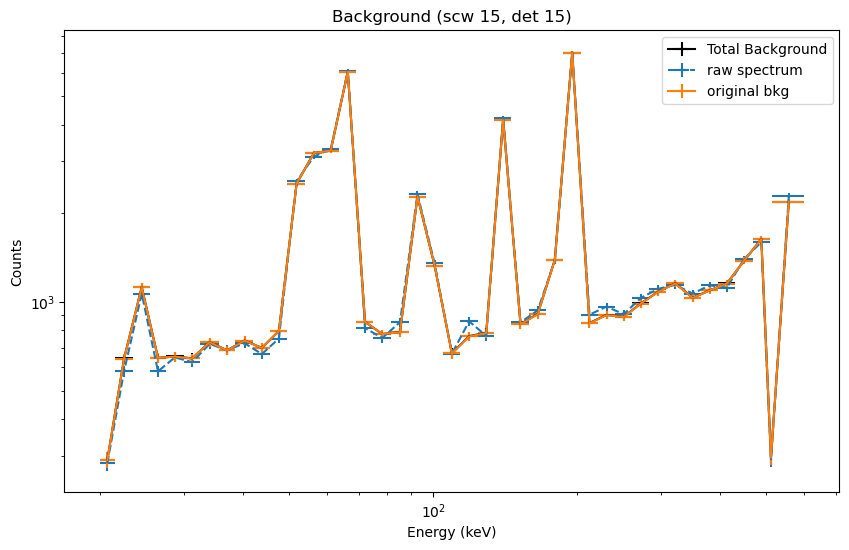

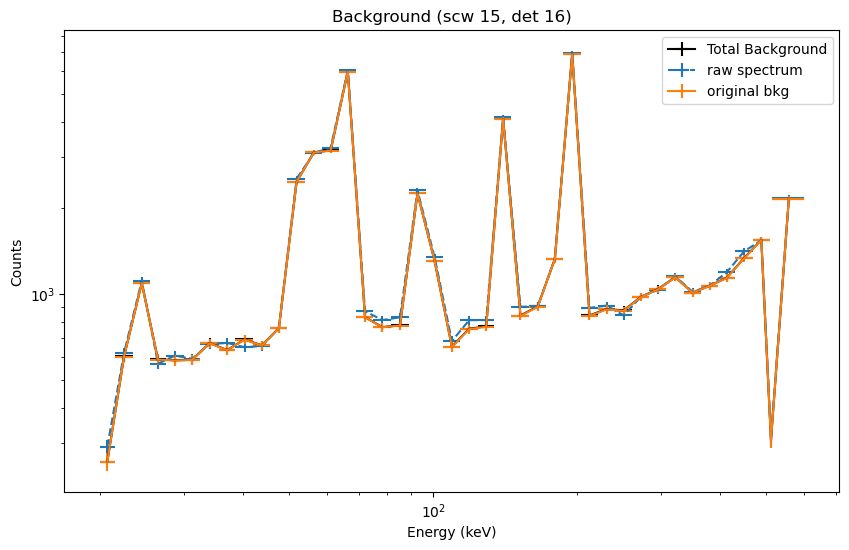

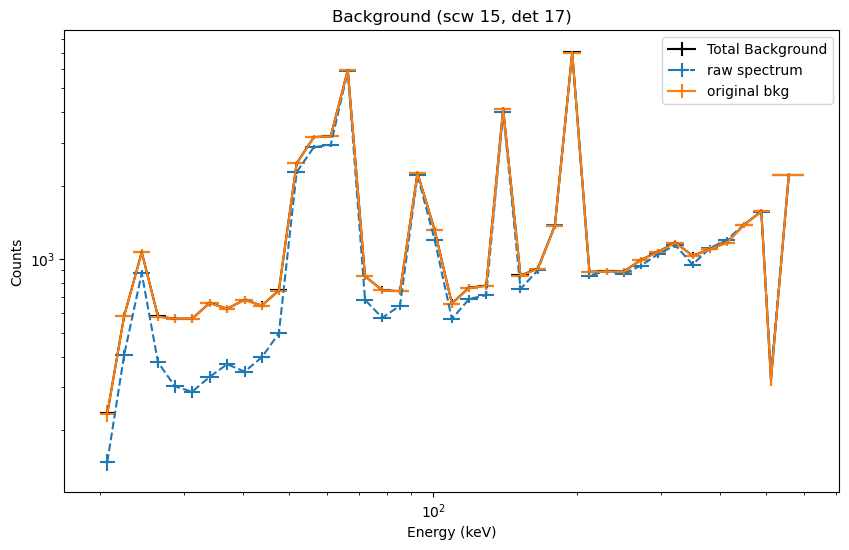

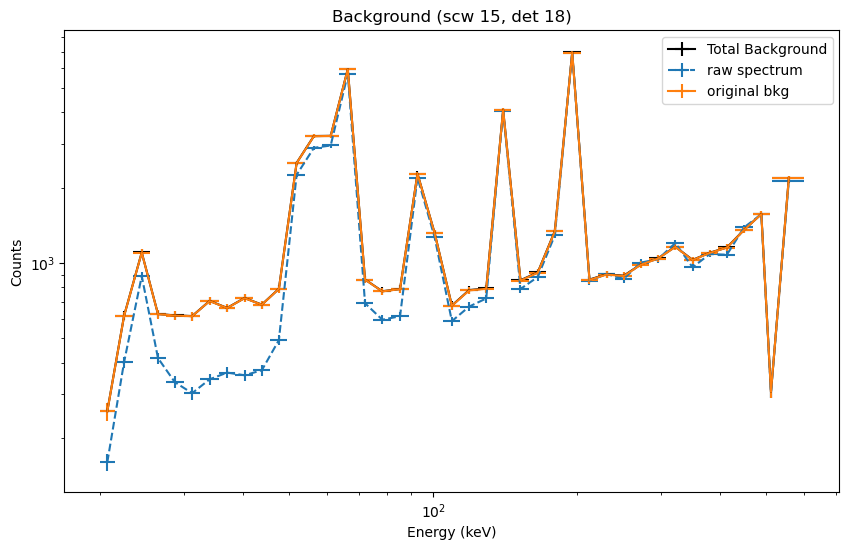

In [6]:
evts_name = f'{main_dir}/spi/evts_det_spec.fits.gz'
# poin_name = [strtrim(string('/pointing.fits.gz'),1),strtrim(string('/pointings.fits.gz'),1)]
# e_lo, e_hi = 30, 350 # kev
# SE_range =  18.25 + np.arange(3964) * 0.5
# E_idx_mask = (SE_range>e_lo) & (SE_range<e_hi)
scw_raw_spec = fits.open(evts_name)[1].data
scw_idx = 15
for det in range(19):
    # fig, ax=plt.subplots(1,1)
    ax=obs_bkg.plot_bkg(scw_idx,det,bkg_types=None)
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y=scw_raw_spec[scw_idx*19+det][0], yerr=scw_raw_spec[scw_idx*19+det][1],ls='--', label='raw spectrum')
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_conti[scw_idx*19+det][0]+data_sumlines[scw_idx*19+det][0],
                yerr=np.sqrt(data_conti[scw_idx*19+det][1]**2+data_sumlines[scw_idx*19+det][1]**2),label='original bkg')
    # ax.errorbar( bkg_spectrum, yerr=np.sqrt(bkg_spectrum), fmt='k-', label=label)
    ax.set_xlabel('Energy (keV)')
    ax.legend()
    ax.loglog()
    plt.show()

## spi init 

(0.0, 130.66239301330228)

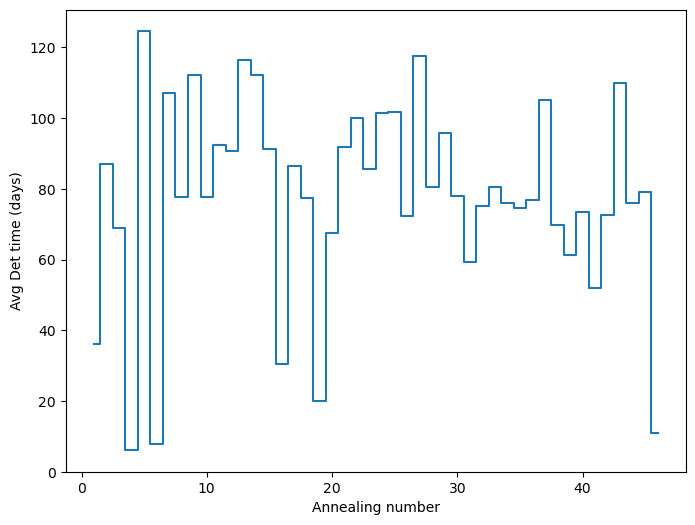

In [34]:
# init_sav_he = readsav('/Users/tbastro/SPI_analysis/BACKGROUND/spi_init_saves_HE.sav')
# init_sav_he['det_time_ann'].shape
init_sav_ann = readsav('/Users/tbastro/SPI_analysis/BACKGROUND/spi_init_saves_ann.sav')
avg_ann_time = init_sav_ann['det_time_ann'].mean(axis=1)
fig, ax=plt.subplots(1,1,figsize=(8,6))
ax.step(x=np.arange(1,len(avg_ann_time)+1), y=avg_ann_time/(3600*24), where='mid')
ax.set_ylabel('Avg Det time (days)')
ax.set_xlabel('Annealing number')
ax.set_ylim(0)